In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║         INDIA AIR QUALITY — COMPLETE PREPROCESSING PIPELINE                ║
# ║         Dataset: city_day.csv (2015–2020)                                  ║
# ║         Steps: 0 to 10 + Visualization + Model Ready Output                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import zipfile
import os
import re
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')          # remove this line if running in Jupyter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler


In [3]:
# STEP 0 — EXTRACT ZIP
# ══════════════════════════════════════════════════════════════════════════════
zip_path       = "Air Quality Data in India (2015 - 2020) archive (4).zip"
extract_folder = "dataset"

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("STEP 0 ✅ Files extracted:", os.listdir(extract_folder))


STEP 0 ✅ Files extracted: ['city_day.csv', 'station_hour.csv', 'city_hour.csv', 'station_day.csv', 'stations.csv']


In [4]:
# STEP 1 — LOAD DATA
# We use city_day.csv — one row per city per day. Cleanest aggregation level.
# city_hour is too granular; station files are sensor-level (too raw).
# ══════════════════════════════════════════════════════════════════════════════
df = pd.read_csv(os.path.join(extract_folder, "city_day.csv"))

print(f"\nSTEP 1 ✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print("Columns:", list(df.columns))
print(df.head(3).to_string())


STEP 1 ✅ Loaded: 29531 rows × 16 columns
Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2      O3  Benzene  Toluene  Xylene  AQI AQI_Bucket
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64  133.36     0.00     0.02    0.00  NaN        NaN
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   34.06     3.68     5.50    3.77  NaN        NaN
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   30.70     6.80    16.40    2.25  NaN        NaN


In [5]:
# STEP 2 — INITIAL INSPECTION
# X-ray the data before touching anything.
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("STEP 2 — INITIAL INSPECTION")
print("─"*60)

print("\n[df.info()]")
df.info()

print("\n[df.describe()]")
print(df.describe(include="all").round(2).to_string())

print("\n[Missing values per column]")
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
for col in df.columns:
    print(f"  {col:15}: {missing[col]:5} missing  ({missing_pct[col]}%)")

print("\n[AQI_Bucket unique values]")
print(df["AQI_Bucket"].value_counts())

print("\n[Cities in dataset]")
print(df["City"].value_counts())

print(f"\nDate range: {df['Date'].min()}  →  {df['Date'].max()}")


────────────────────────────────────────────────────────────
STEP 2 — INITIAL INSPECTION
────────────────────────────────────────────────────────────

[df.info()]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-nul

In [6]:
# STEP 2b — DATE CONVERSION + FEATURE EXTRACTION
# ─ WHY: Date stored as string → Python can't do time math on it.
# ─ We extract Year, Month, Season — useful features for pollution patterns.
# ─ YOUR MISTAKE WAS: converting column "Day" then calling set_index("Date")
#   → KeyError because "Date" wasn't converted yet. Always convert first.
# ══════════════════════════════════════════════════════════════════════════════
df["Date"]  = pd.to_datetime(df["Date"])     # string → datetime
df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Season"] = df["Month"].map({
    12: "Winter", 1: "Winter",  2: "Winter",
    3:  "Spring",  4: "Spring",  5: "Spring",
    6:  "Monsoon", 7: "Monsoon", 8: "Monsoon",
    9:  "Autumn", 10: "Autumn", 11: "Autumn"
})

print("\nSTEP 2b ✅ Date converted | Year / Month / Season extracted")



STEP 2b ✅ Date converted | Year / Month / Season extracted


In [7]:
# STEP 3 — HANDLE MISSING VALUES
# CORRECT APPROACH for time-series environmental data:
#   1. Drop Xylene (61% missing — no sensor data, not fixable)
#   2. Sort by City + Date first (time order matters!)
#   3. ffill() within each city → "yesterday's reading is today's best estimate"
#   4. bfill() to catch any leading NaNs at start of each city's timeline
#   5. For cities with entire column missing (Lucknow PM10 — no sensor installed)
#      fill with global median as last resort
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("STEP 3 — HANDLING MISSING VALUES")
print("─"*60)

# 3a. Drop Xylene — 61% missing, no sensor coverage, cannot impute reliably
df.drop(columns=["Xylene"], inplace=True)
print("  → Xylene DROPPED (61% missing — more than half the column is empty)")


────────────────────────────────────────────────────────────
STEP 3 — HANDLING MISSING VALUES
────────────────────────────────────────────────────────────
  → Xylene DROPPED (61% missing — more than half the column is empty)


In [8]:
# 3b. Sort by City + Date so ffill works in time order
df.sort_values(["City", "Date"], inplace=True)
df.reset_index(drop=True, inplace=True)

# 3c. ffill + bfill within each city group
pollutant_cols = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3",
                  "CO", "SO2", "O3", "Benzene", "Toluene", "AQI"]

for col in pollutant_cols:
    df[col] = df.groupby("City")[col].transform(
        lambda x: x.ffill().bfill()
    )

# 3d. Cities with entire column missing → global median as last resort
for col in pollutant_cols:
    df[col].fillna(df[col].median(), inplace=True)

# 3e. AQI_Bucket — re-derive from AQI using official CPCB scale
#     NEVER fill categorically when you can re-compute from a numeric column
def assign_bucket(aqi):
    if   aqi <= 50:  return "Good"
    elif aqi <= 100: return "Satisfactory"
    elif aqi <= 200: return "Moderate"
    elif aqi <= 300: return "Poor"
    elif aqi <= 400: return "Very Poor"
    else:            return "Severe"

df["AQI_Bucket"] = df["AQI"].apply(assign_bucket)

print(f"\n  Missing values after Step 3: {df.isnull().sum().sum()}")
print("STEP 3 ✅ Missing values handled")




  Missing values after Step 3: 0
STEP 3 ✅ Missing values handled


In [9]:
# STEP 4 — HANDLE DUPLICATES
# Check on City+Date combination — the logical primary key of this dataset.
# A row is a duplicate if same city recorded twice on the same day.
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("STEP 4 — DUPLICATES")
print("─"*60)

dups = df.duplicated(subset=["City", "Date"]).sum()
print(f"  Duplicate City+Date rows: {dups}")

if dups > 0:
    df.drop_duplicates(subset=["City", "Date"], inplace=True)
    print(f"  Removed. New shape: {df.shape}")
else:
    print("  No duplicates found ✅")




────────────────────────────────────────────────────────────
STEP 4 — DUPLICATES
────────────────────────────────────────────────────────────
  Duplicate City+Date rows: 0
  No duplicates found ✅


In [10]:
# STEP 5 — OUTLIER DETECTION & TREATMENT
print("\n" + "─"*60)
print("STEP 5 — OUTLIER DETECTION & CAPPING")
print("─"*60)

def cap_iqr(series, factor=3.0):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    print(f"    Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}  "
          f"Fence=[{lower:.2f}, {upper:.2f}]  "
          f"Outliers={(series < lower).sum() + (series > upper).sum()}")
    return series.clip(lower, upper)

cap_cols = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3", "AQI"]

for col in cap_cols:
    print(f"  {col}:")
    df[col] = cap_iqr(df[col])

print("STEP 5 ✅ Outliers capped (not removed)")


────────────────────────────────────────────────────────────
STEP 5 — OUTLIER DETECTION & CAPPING
────────────────────────────────────────────────────────────
  PM2.5:
    Q1=27.03  Q3=86.97  IQR=59.94  Fence=[-152.79, 266.79]  Outliers=560
  PM10:
    Q1=58.53  Q3=150.90  IQR=92.37  Fence=[-218.59, 428.03]  Outliers=249
  NO2:
    Q1=10.45  Q3=35.03  IQR=24.58  Fence=[-63.29, 108.77]  Outliers=369
  SO2:
    Q1=5.76  Q3=18.17  IQR=12.41  Fence=[-31.47, 55.40]  Outliers=2626
  CO:
    Q1=0.50  Q3=1.49  IQR=0.99  Fence=[-2.47, 4.46]  Outliers=2389
  O3:
    Q1=17.24  Q3=44.22  IQR=26.98  Fence=[-63.69, 125.14]  Outliers=108
  AQI:
    Q1=78.00  Q3=211.00  IQR=133.00  Fence=[-321.00, 610.00]  Outliers=319
STEP 5 ✅ Outliers capped (not removed)


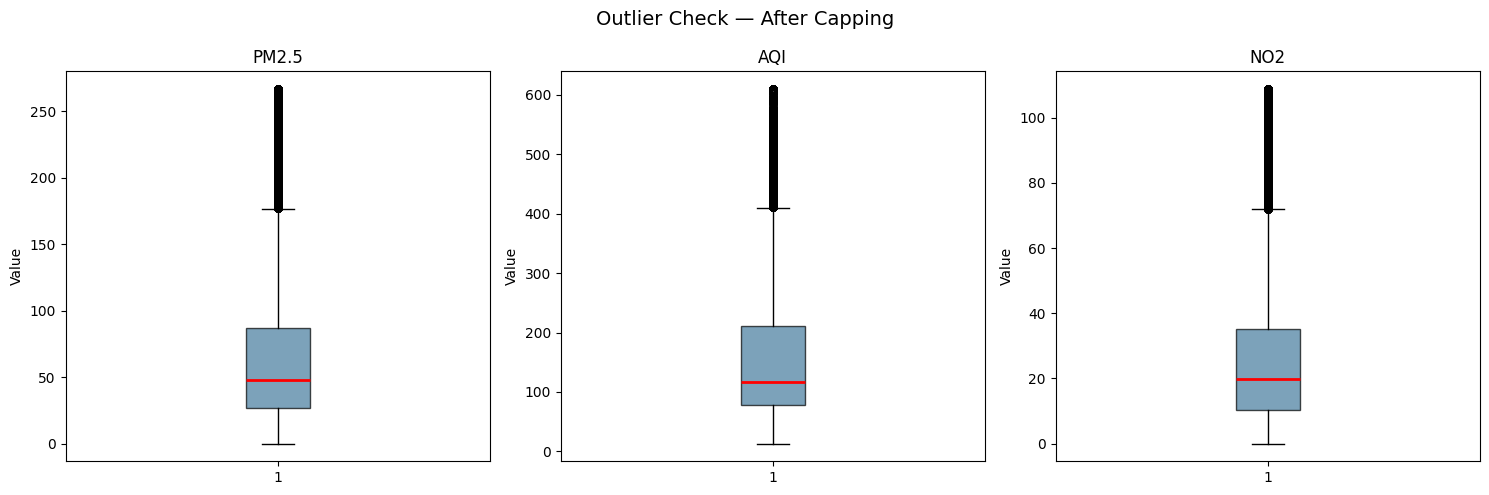

In [18]:
import matplotlib.pyplot as plt

cols = ["PM2.5", "AQI", "NO2"]

# ✅ Check columns exist
for col in cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame")

# ✅ Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Outlier Check — After Capping", fontsize=14)

for ax, col in zip(axes, cols):
    data = df[col].dropna()

    # 🚨 If no data, show message instead of blank plot
    if data.empty:
        ax.text(0.5, 0.5, "No Data", ha='center', va='center')
        ax.set_title(col)
        continue

    ax.boxplot(data,
               patch_artist=True,
               boxprops=dict(facecolor="#457B9D", alpha=0.7),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", markersize=5))

    ax.set_title(col)
    ax.set_ylabel("Value")

plt.tight_layout()

# 🔥 FORCE DISPLAY
display(fig)

In [19]:
#STEP 7 — FEATURE ENGINEERING
print("\n" + "─"*60)
print("STEP 7 — FEATURE ENGINEERING")
print("─"*60)
# Feature 1: Combustion Index
# NO2 + CO both come from burning (vehicles + industry) — same unit (μg/m³)
# Higher value = more burning happening in the city
df["Combustion_Index"] = (df["NO2"] + df["CO"]).round(2)
print("  ✅ Combustion_Index = NO2 + CO  (traffic + industrial burning signal)")



────────────────────────────────────────────────────────────
STEP 7 — FEATURE ENGINEERING
────────────────────────────────────────────────────────────
  ✅ Combustion_Index = NO2 + CO  (traffic + industrial burning signal)


In [25]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Month,Combustion_Index,Smog_Risk,PM_Ratio,Is_Winter,High_Pollution_Day,Pollution_Level,Season_Monsoon,Season_Spring,Season_Winter
0,Ahmedabad,2015-01-01,73.24,141.54,0.92,18.22,17.15,16.54,0.92,27.64,...,1,19.14,22.80,0.517,1,1,3,False,False,True
1,Ahmedabad,2015-01-02,73.24,141.54,0.97,15.69,16.46,16.54,0.97,24.55,...,1,16.66,5.34,0.517,1,1,3,False,False,True
2,Ahmedabad,2015-01-03,73.24,141.54,17.40,19.30,29.70,16.54,4.46,29.07,...,1,23.76,5.93,0.517,1,1,3,False,False,True
3,Ahmedabad,2015-01-04,73.24,141.54,1.70,18.48,17.97,16.54,1.70,18.59,...,1,20.18,6.67,0.517,1,1,3,False,False,True
4,Ahmedabad,2015-01-05,73.24,141.54,22.10,21.42,37.76,16.54,4.46,39.33,...,1,25.88,8.42,0.517,1,1,3,False,False,True


In [20]:
# Feature 2: Smog Risk
# O3 is created when sunlight reacts with NO2 (photochemical reaction)
# High O3 + High NO2 together = dangerous smog forming conditions
df["Smog_Risk"] = (df["O3"] * df["NO2"] / 100).round(2)
print("  ✅ Smog_Risk = O3 × NO2 / 100  (photochemical smog indicator)")

  ✅ Smog_Risk = O3 × NO2 / 100  (photochemical smog indicator)


In [26]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Month,Combustion_Index,Smog_Risk,PM_Ratio,Is_Winter,High_Pollution_Day,Pollution_Level,Season_Monsoon,Season_Spring,Season_Winter
0,Ahmedabad,2015-01-01,73.24,141.54,0.92,18.22,17.15,16.54,0.92,27.64,...,1,19.14,22.80,0.517,1,1,3,False,False,True
1,Ahmedabad,2015-01-02,73.24,141.54,0.97,15.69,16.46,16.54,0.97,24.55,...,1,16.66,5.34,0.517,1,1,3,False,False,True
2,Ahmedabad,2015-01-03,73.24,141.54,17.40,19.30,29.70,16.54,4.46,29.07,...,1,23.76,5.93,0.517,1,1,3,False,False,True
3,Ahmedabad,2015-01-04,73.24,141.54,1.70,18.48,17.97,16.54,1.70,18.59,...,1,20.18,6.67,0.517,1,1,3,False,False,True
4,Ahmedabad,2015-01-05,73.24,141.54,22.10,21.42,37.76,16.54,4.46,39.33,...,1,25.88,8.42,0.517,1,1,3,False,False,True


In [21]:
# Feature 3: PM Ratio
# PM2.5 / PM10 tells us the TYPE of particles
# High ratio → mostly fine particles (vehicle exhaust, burning)
# Low ratio  → mostly coarse particles (dust, construction)
df["PM_Ratio"] = (df["PM2.5"] / (df["PM10"] + 0.001)).round(3)
print("  ✅ PM_Ratio = PM2.5 / PM10  (particle source detector)")

# Feature 4: Is Winter (binary flag)
# Winter = temperature inversion traps pollution near ground
# Worst pollution months across all Indian cities
df["Is_Winter"] = df["Season"].apply(lambda x: 1 if x == "Winter" else 0)
print("  ✅ Is_Winter  (1=Winter months Dec/Jan/Feb, 0=rest)")

# Feature 5: High Pollution Day flag
# AQI > 200 = Poor category → immediate health warnings issued
df["High_Pollution_Day"] = (df["AQI"] > 200).astype(int)
print("  ✅ High_Pollution_Day  (1 if AQI > 200, 0 otherwise)")

print(f"\n  New shape after feature engineering: {df.shape}")

  ✅ PM_Ratio = PM2.5 / PM10  (particle source detector)
  ✅ Is_Winter  (1=Winter months Dec/Jan/Feb, 0=rest)
  ✅ High_Pollution_Day  (1 if AQI > 200, 0 otherwise)

  New shape after feature engineering: (29531, 23)


In [24]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Month,Combustion_Index,Smog_Risk,PM_Ratio,Is_Winter,High_Pollution_Day,Pollution_Level,Season_Monsoon,Season_Spring,Season_Winter
0,Ahmedabad,2015-01-01,73.24,141.54,0.92,18.22,17.15,16.54,0.92,27.64,...,1,19.14,22.80,0.517,1,1,3,False,False,True
1,Ahmedabad,2015-01-02,73.24,141.54,0.97,15.69,16.46,16.54,0.97,24.55,...,1,16.66,5.34,0.517,1,1,3,False,False,True
2,Ahmedabad,2015-01-03,73.24,141.54,17.40,19.30,29.70,16.54,4.46,29.07,...,1,23.76,5.93,0.517,1,1,3,False,False,True
3,Ahmedabad,2015-01-04,73.24,141.54,1.70,18.48,17.97,16.54,1.70,18.59,...,1,20.18,6.67,0.517,1,1,3,False,False,True
4,Ahmedabad,2015-01-05,73.24,141.54,22.10,21.42,37.76,16.54,4.46,39.33,...,1,25.88,8.42,0.517,1,1,3,False,False,True


In [22]:
# STEP 8 — ENCODING
print("\n" + "─"*60)
print("STEP 8 — ENCODING")
print("─"*60)

# Method 1: Manual ordered mapping for AQI_Bucket
# ORDER: Good < Satisfactory < Moderate < Poor < Very Poor < Severe
bucket_order = {
    "Good": 0, "Satisfactory": 1, "Moderate": 2,
    "Poor": 3, "Very Poor": 4,   "Severe": 5
}
df["Pollution_Level"] = df["AQI_Bucket"].map(bucket_order)
print("  ✅ AQI_Bucket → Pollution_Level (manual ordered map: 0=Good to 5=Severe)")


────────────────────────────────────────────────────────────
STEP 8 — ENCODING
────────────────────────────────────────────────────────────
  ✅ AQI_Bucket → Pollution_Level (manual ordered map: 0=Good to 5=Severe)


In [27]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Month,Combustion_Index,Smog_Risk,PM_Ratio,Is_Winter,High_Pollution_Day,Pollution_Level,Season_Monsoon,Season_Spring,Season_Winter
0,Ahmedabad,2015-01-01,73.24,141.54,0.92,18.22,17.15,16.54,0.92,27.64,...,1,19.14,22.80,0.517,1,1,3,False,False,True
1,Ahmedabad,2015-01-02,73.24,141.54,0.97,15.69,16.46,16.54,0.97,24.55,...,1,16.66,5.34,0.517,1,1,3,False,False,True
2,Ahmedabad,2015-01-03,73.24,141.54,17.40,19.30,29.70,16.54,4.46,29.07,...,1,23.76,5.93,0.517,1,1,3,False,False,True
3,Ahmedabad,2015-01-04,73.24,141.54,1.70,18.48,17.97,16.54,1.70,18.59,...,1,20.18,6.67,0.517,1,1,3,False,False,True
4,Ahmedabad,2015-01-05,73.24,141.54,22.10,21.42,37.76,16.54,4.46,39.33,...,1,25.88,8.42,0.517,1,1,3,False,False,True


In [23]:
# Method 2: One-Hot Encoding for Season (no natural order)
# drop_first=True → avoids Dummy Variable Trap (multicollinearity)
df = pd.get_dummies(df, columns=["Season"], prefix="Season", drop_first=True)
print("  ✅ Season → OHE columns (drop_first=True to avoid dummy variable trap)")
print(f"  Season columns created: {[c for c in df.columns if 'Season_' in c]}")


  ✅ Season → OHE columns (drop_first=True to avoid dummy variable trap)
  Season columns created: ['Season_Monsoon', 'Season_Spring', 'Season_Winter']


In [29]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Month,Combustion_Index,Smog_Risk,PM_Ratio,Is_Winter,High_Pollution_Day,Pollution_Level,Season_Monsoon,Season_Spring,Season_Winter
0,Ahmedabad,2015-01-01,73.24,141.54,0.92,18.22,17.15,16.54,0.92,27.64,...,1,19.14,22.80,0.517,1,1,3,False,False,True
1,Ahmedabad,2015-01-02,73.24,141.54,0.97,15.69,16.46,16.54,0.97,24.55,...,1,16.66,5.34,0.517,1,1,3,False,False,True
2,Ahmedabad,2015-01-03,73.24,141.54,17.40,19.30,29.70,16.54,4.46,29.07,...,1,23.76,5.93,0.517,1,1,3,False,False,True
3,Ahmedabad,2015-01-04,73.24,141.54,1.70,18.48,17.97,16.54,1.70,18.59,...,1,20.18,6.67,0.517,1,1,3,False,False,True
4,Ahmedabad,2015-01-05,73.24,141.54,22.10,21.42,37.76,16.54,4.46,39.33,...,1,25.88,8.42,0.517,1,1,3,False,False,True


In [28]:
print("\n" + "─"*60)
print("STEP 9 — FEATURE SCALING")
print("─"*60)

# Features for ML — raw pollutants only (AQI excluded to prevent data leakage)
feature_cols = [
    "PM2.5", "PM10", "NO", "NO2", "NOx", "NH3",
    "CO", "SO2", "O3", "Benzene", "Toluene",
    "Combustion_Index", "Smog_Risk", "PM_Ratio"
]

# NOT scaled: Is_Winter, High_Pollution_Day, Season_* (binary / OHE)
# NOT scaled: Pollution_Level (this is our TARGET variable)

scaler   = StandardScaler()
df_ml    = df.copy()                                      # keep original safe
df_ml[feature_cols] = scaler.fit_transform(df[feature_cols])

print("  Columns scaled:", feature_cols)
print("  Verification — mean should ≈ 0, std should ≈ 1:")
print(df_ml[feature_cols].describe().loc[["mean", "std"]].round(3).to_string())
print("STEP 9 ✅ StandardScaler applied")


────────────────────────────────────────────────────────────
STEP 9 — FEATURE SCALING
────────────────────────────────────────────────────────────
  Columns scaled: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Combustion_Index', 'Smog_Risk', 'PM_Ratio']
  Verification — mean should ≈ 0, std should ≈ 1:
      PM2.5  PM10   NO  NO2  NOx  NH3   CO  SO2   O3  Benzene  Toluene  Combustion_Index  Smog_Risk  PM_Ratio
mean   -0.0  -0.0  0.0  0.0 -0.0  0.0  0.0  0.0  0.0     -0.0      0.0              -0.0        0.0       0.0
std     1.0   1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0      1.0      1.0               1.0        1.0       1.0
STEP 9 ✅ StandardScaler applied


In [30]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Month,Combustion_Index,Smog_Risk,PM_Ratio,Is_Winter,High_Pollution_Day,Pollution_Level,Season_Monsoon,Season_Spring,Season_Winter
0,Ahmedabad,2015-01-01,73.24,141.54,0.92,18.22,17.15,16.54,0.92,27.64,...,1,19.14,22.80,0.517,1,1,3,False,False,True
1,Ahmedabad,2015-01-02,73.24,141.54,0.97,15.69,16.46,16.54,0.97,24.55,...,1,16.66,5.34,0.517,1,1,3,False,False,True
2,Ahmedabad,2015-01-03,73.24,141.54,17.40,19.30,29.70,16.54,4.46,29.07,...,1,23.76,5.93,0.517,1,1,3,False,False,True
3,Ahmedabad,2015-01-04,73.24,141.54,1.70,18.48,17.97,16.54,1.70,18.59,...,1,20.18,6.67,0.517,1,1,3,False,False,True
4,Ahmedabad,2015-01-05,73.24,141.54,22.10,21.42,37.76,16.54,4.46,39.33,...,1,25.88,8.42,0.517,1,1,3,False,False,True


In [31]:
# STEP 10 — FINAL DATASET & VERIFICATION
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("STEP 10 — FINAL VERIFICATION & SAVE")
print("─"*60)

# Drop columns not needed for ML
drop_cols = ["AQI_Bucket"]    # replaced by Pollution_Level
df_final  = df_ml.drop(columns=drop_cols)

print(f"  Shape           : {df_final.shape}")
print(f"  Missing values  : {df_final.isnull().sum().sum()}  ← must be 0")
print(f"  Duplicate rows  : {df_final.duplicated().sum()}  ← must be 0")
print(f"\n  Data types:\n{df_final.dtypes.to_string()}")
print(f"\n  First 3 rows:\n{df_final.head(3).to_string()}")

# Save both versions
df.to_csv("city_day_clean.csv",    index=False)   # human-readable, original scale
df_final.to_csv("city_day_ml.csv", index=False)   # scaled, encoded, ML-ready

print("\nSTEP 10 ✅ Saved:")
print("  → city_day_clean.csv  (clean, original scale, for EDA & visualization)")
print("  → city_day_ml.csv     (scaled + encoded, ready for ML model)")



────────────────────────────────────────────────────────────
STEP 10 — FINAL VERIFICATION & SAVE
────────────────────────────────────────────────────────────
  Shape           : (29531, 25)
  Missing values  : 0  ← must be 0
  Duplicate rows  : 0  ← must be 0

  Data types:
City                          object
Date                  datetime64[ns]
PM2.5                        float64
PM10                         float64
NO                           float64
NO2                          float64
NOx                          float64
NH3                          float64
CO                           float64
SO2                          float64
O3                           float64
Benzene                      float64
Toluene                      float64
AQI                          float64
Year                           int32
Month                          int32
Combustion_Index             float64
Smog_Risk                    float64
PM_Ratio                     float64
Is_Winter            